In [1]:
from flax.nnx.bridge import nnx_in_bridge_mdl
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from IPython.display import Image
from jax import numpy as jnp
import jax
from flax import  nnx
from functools import partial
from QNN_jax import  quantum_neural_network,data_encoding,initialize_parameters

In [2]:
dev = qml.device("default.qubit", wires=4)
qnode = qml.QNode(func=quantum_neural_network, device=dev,interface='jax')
# x是每一次输入的构型S 例如S =[1,0,1,0]
qnode(x=[1,0,1,0],params=initialize_parameters(2,4),n_layers=2,n_qubits=4)

[Array(0.26316482, dtype=float32),
 Array(-0.1941959, dtype=float32),
 Array(-0.06452206, dtype=float32),
 Array(-0.14248529, dtype=float32)]

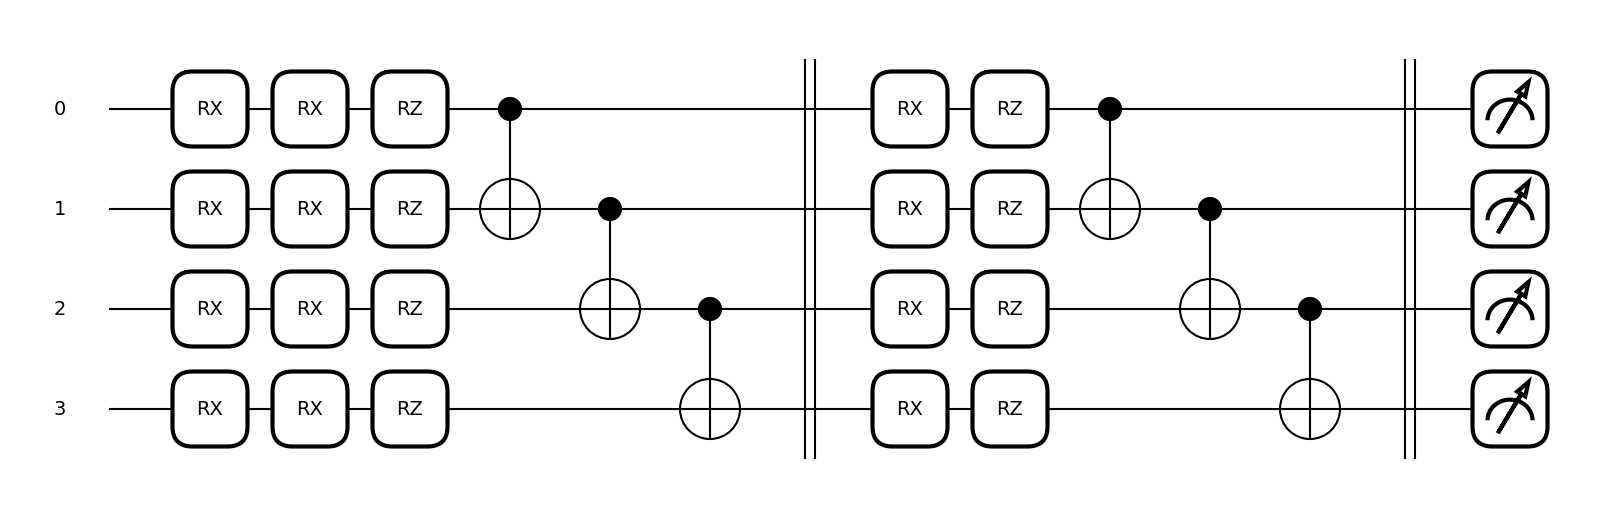

In [3]:
import matplotlib.pyplot as plt
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(qnode)(x=[1,0,1,0],params=initialize_parameters(2,4),n_layers=2,n_qubits=4)
plt.show()

尝试把 QNN jax化

In [4]:
def qnn_circuit(n_qubits:int,n_layers:int):
    dev = qml.device('default.qubit',wires=n_qubits)
    pqc_node = qml.QNode(func=quantum_neural_network,device=dev,interface='jax')
    qnn_node_circuit = partial(pqc_node,n_qubits=n_qubits,n_layers=n_layers)
    return qnn_node_circuit

In [5]:
qnn_func = qnn_circuit(n_qubits=4,n_layers=2)
qnn_func(params=initialize_parameters(2,4),x=[1,0,1,0])

[Array(-0.9630001, dtype=float32),
 Array(-0.24106339, dtype=float32),
 Array(0.16867581, dtype=float32),
 Array(0.23926988, dtype=float32)]

In [6]:
def qnn_circuit(n_qubits:int,n_layers:int):
    dev = qml.device('default.qubit',wires=n_qubits)
    pqc_node = qml.QNode(func=quantum_neural_network,device=dev,interface='jax')
    qnn_node_circuit = partial(pqc_node,n_qubits=n_qubits,n_layers=n_layers)
    return qnn_node_circuit

In [7]:
from flax import nnx
from functools import partial
class QNNLinear(nnx.Module):
    def __init__(self, rngs: nnx.Rngs,n_qubits:int,n_layer:int):
        self.rngs = rngs
        self.key = rngs.params()
        self.n_qubits,self.n_layer = n_qubits,n_layer
        self.qnn_params = nnx.Param(jax.random.normal(self.key,(self.n_qubits,self.n_layer)))
        self.qnn_layer = partial(qnn_circuit, n_qubits=self.n_qubits,n_layers=self.n_layer)()
        self.Linear = nnx.Linear(in_features=self.n_qubits,out_features=self.n_qubits,use_bias=False,rngs=self.rngs)
        
    
    def __call__(self, s:np.array):
        qnn_output = self.qnn_layer(x=s,params=self.qnn_params)
        y = self.Linear(qnn_output)
        return jnp.sum(y, axis=-1)
        

In [8]:
model = QNNLinear(n_qubits=4,n_layer=2,rngs=nnx.Rngs(params=0))

In [9]:
model(s=[1,0,1,0])

Array(-0.01792514, dtype=float32)

接下来在$H_2$分子的VMC中尝试使用这个经典-量子混合模型作为 Ansatz

In [10]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H2分子的几何构型
bond_length = 0.74  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hartree-Fock能量: -1.11675931 Ha
FCI能量: -1.13728383 Ha


In [11]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(1, 1)  # 每种自旋的电子数
)

# 创建采样器 - 使用费米子跳跃采样器
# 对于分子系统，我们使用完整的轨道图（完全连接）
cluster = [(0,1),(2,3)]
#

# g = nk.graph.Graph(edges=[(0,2),(1,3),(2,0),(3,1)])
g = nk.graph.Graph(edges=[(0,1),(2,3)])
# g = nk.graph.Graph(edges=cluster)
sampler = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [12]:
from flax import nnx
from functools import partial
import jax

model = QNNLinear(rngs=nnx.Rngs(2),n_qubits=4, n_layer=2)


In [13]:
model(s = [1,0,1,0])

Array(-0.39078337, dtype=float64)

In [14]:
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)

ValueError: 输入数据的长度必须等于量子比特数量